In [1]:
# Lecture 7
# import packages
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
from scipy.special import logit, expit

from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
# os.chdir(r'C:\Users\Linda\Desktop\ST5213py')
pd.set_option("display.width", 2000)

# import custom functions
from ST5213_helpers import *

# fig_save_dir = r'C:/Users/Linda/OneDrive - National University of Singapore/ST5213 2627/Lectures/Lecture_7/figure'

In [2]:
# Case-control study on cervical cancer
df = pd.DataFrame({'age': ['<=15', '>15'], 'cases': [36, 11], 'controls': [78, 95]})

# Assign age as categorical and change baseline to >15
df['age'] = pd.Categorical(df['age'], categories=['>15', '<=15'], ordered=True)
print(df.info(), '\n')
print(df, '\n')

# Fit GLM
fm = glm('cases + controls ~ age', df, family=Binomial()).fit() 
print(fm.summary2(), '\n')
print(anova_single(fm), '\n')

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   age       2 non-null      category
 1   cases     2 non-null      int64   
 2   controls  2 non-null      int64   
dtypes: category(1), int64(2)
memory usage: 290.0 bytes
None 

    age  cases  controls
0  <=15     36        78
1   >15     11        95 

                 Results: Generalized linear model
Model:              GLM                   Method:         IRLS      
Model Family:       Binomial              AIC:            13.1888   
Link Function:      Logit                 BIC:            10.5750   
Dependent Variable: ['cases', 'controls'] Log-Likelihood: -4.5944   
Date:               2026-09-29 14:33      LL-Null:        -12.290   
No. Observations:   2                     Deviance:       4.4409e-16
Df Model:           1                     Pearson chi2:   1.62e-26  
Df Residuals:       0                

c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\regression\_tools.py:133: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\regression\_tools.py:133: RuntimeWarning: divide by zero encountered in scalar divide
  scale = np.dot(wresid, wresid) / df_resid
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(


In [3]:
# Get coefficients of fm and compute odds
beta = np.array(fm.params)
print(beta)
print(np.exp(beta))

# Get standard error of coefficients 
SE = np.array(fm.bse)
print(SE)

# Compute CI for odds ratio
lgOR_CI = beta[1] + np.array([-1,1]) * norm.ppf(0.975) * SE[1]  # CI for log odds ratio
print(np.exp(lgOR_CI))                                          # CI for odds ratio

[-2.15598162  1.38279173]
[0.11578947 3.98601399]
[0.31848922 0.37687355]
[1.90433554 8.343229  ]


In [5]:
# read HD1 dataset
df = pd.read_csv('dataset/HD1.txt', sep=' ')
print(df.head(),'\n')

# Convert y to binary variable with 1 as baseline category to model P(Y=1)
df['y'] = pd.Categorical(df['y'], categories=[1, 0], ordered=True)
print(df.info())

          x  y
0 -0.202796  0
1 -0.828338  0
2  0.016841  1
3  0.373403  1
4 -0.184950  0 

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   x       30 non-null     float64 
 1   y       30 non-null     category
dtypes: category(1), float64(1)
memory usage: 526.0 bytes
None


In [6]:
# Fit GLM to HD1
fm = glm(formula='y ~ x', data=df, family=Binomial()).fit()
print(fm.summary(),'\n')
print(anova_single(fm))

                 Generalized Linear Model Regression Results                  
Dep. Variable:       ['y[1]', 'y[0]']   No. Observations:                   30
Model:                            GLM   Df Residuals:                       28
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.9632e-09
Date:                Tue, 29 Sep 2026   Deviance:                   3.9263e-09
Time:                        14:35:51   Pearson chi2:                 1.96e-09
No. Iterations:                    26   Pseudo R-squ. (CS):             0.7489
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.9831   1.47e+04      0.001      0.9

c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages

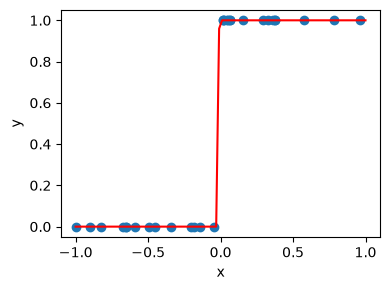

In [7]:
# plot HD1 
xnew = np.linspace(-1,1,100)
dfnew = pd.DataFrame({'x': xnew})

plt.figure(figsize=(4, 3))
plt.scatter(df['x'], df['y'])
plt.plot(xnew, fm.predict(dfnew), 'r-')
plt.xlabel('x')
plt.ylabel('y')
plt.tight_layout() 

# fig_path = os.path.join(fig_save_dir, 'hd1.pdf')
# plt.savefig(fig_path, bbox_inches='tight')  

In [8]:
# read HD2 dataset
df = pd.read_csv('dataset/HD2.txt', sep=' ')
print(df.head(),'\n')

# Convert y to binary variable with 1 as baseline category to model P(Y=1)
df['y'] = pd.Categorical(df['y'], categories=[1, 0], ordered=True)
print(df.info(),'\n')

         x1        x2  y
0  0.014956  0.071194  0
1 -0.386463 -0.813824  1
2 -0.146185 -0.660394  1
3  0.386204  0.799665  0
4 -0.829728 -0.154725  1 

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   x1      30 non-null     float64 
 1   x2      30 non-null     float64 
 2   y       30 non-null     category
dtypes: category(1), float64(2)
memory usage: 766.0 bytes
None 



In [9]:
# Fit GLM to HD2
fm = glm(formula='y ~ x1 + x2', data=df, family=Binomial()).fit()
print(fm.summary(),'\n')
print(drop1_glm(fm),'\n')
print(fm.converged)


                 Generalized Linear Model Regression Results                  
Dep. Variable:       ['y[1]', 'y[0]']   No. Observations:                   30
Model:                            GLM   Df Residuals:                       27
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -2.1517e-09
Date:                Tue, 29 Sep 2026   Deviance:                   4.3034e-09
Time:                        14:36:28   Pearson chi2:                 2.15e-09
No. Iterations:                    25   Pseudo R-squ. (CS):             0.7455
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.3385   1.32e+04     -0.000      1.0

c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(
c:\Users\YuxinLi\anaconda3\envs\ST5213\Lib\site-packages\statsmodels\genmod\generalized_linear_model.py:1269: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  return self._fit_irls(


[  -2.33849612 -232.30128171 -209.19705421] 



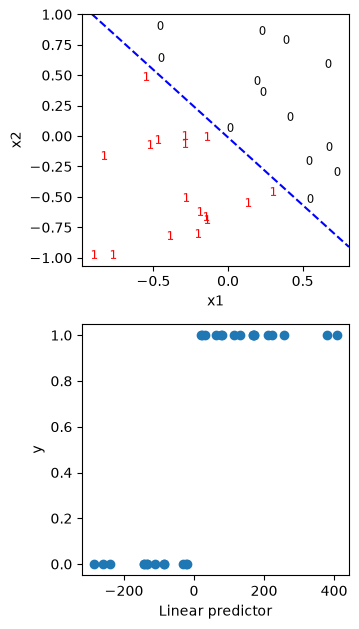

In [10]:
# plot HD2
beta = np.array(fm.params) 
print(beta, '\n')

xnew = np.linspace(-1,1,100)
dfnew = pd.DataFrame({'x': xnew})
y_markers = {0: r'$0$', 1: r'$1$'}
colors ={0: 'black', 1: 'red'}

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(3.6, 6.4))

for y_val, group in df.groupby('y'):
    axes[0].scatter(group['x1'], group['x2'],
        marker=y_markers[y_val], color=colors[y_val], linewidths=0, s=40)

axes[0].axline((0, -beta[0]/beta[2]), slope=-beta[1]/beta[2], color='blue', linewidth=1.5, linestyle='--')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')

axes[1].scatter(fm.predict(df, which='linear'), df['y'])
axes[1].set_xlabel('Linear predictor')
axes[1].set_ylabel('y')

plt.tight_layout() 

# fig_path = os.path.join(fig_save_dir, 'hd2.pdf')
# fig.savefig(fig_path, bbox_inches='tight')  

In [12]:
# Snails dataset

df = pd.read_csv('dataset/snails.txt', sep=' ')
print(df.head(), '\n')

# drop the variables Species, Rel.Hum and Temp
df = df.drop(columns=['Species', 'Rel_Hum', 'Temp'])

# Assign Exposure as categorical 
df['Exposure'] = pd.Categorical(df['Exposure'])
print(df['Exposure'].cat.categories,'\n')

# Create a variable to represent failures 
df['fail'] = df['N'] - df['Deaths']

print(df.info())

  Species  Exposure  Rel_Hum  Temp  Deaths   N
1       A         1     60.0    10       0  20
2       A         1     60.0    15       0  20
3       A         1     60.0    20       0  20
4       A         1     65.8    10       0  20
5       A         1     65.8    15       0  20 

Index([1, 2, 3, 4], dtype='int64') 

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 1 to 96
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Exposure  96 non-null     category
 1   Deaths    96 non-null     int64   
 2   N         96 non-null     int64   
 3   fail      96 non-null     int64   
dtypes: category(1), int64(3)
memory usage: 2.5 KB
None


In [13]:
# Fit GLM
fm = glm('Deaths + fail ~ Exposure', df, family=Binomial()).fit() 
print(fm.summary2(), '\n')
print(drop1_glm(fm), '\n')

                   Results: Generalized linear model
Model:                  GLM                  Method:           IRLS    
Model Family:           Binomial             AIC:              349.2384
Link Function:          Logit                BIC:              359.4958
Dependent Variable:     ['Deaths', 'fail']   Log-Likelihood:   -170.62 
Date:                   2026-09-29 14:42     LL-Null:          -349.29 
No. Observations:       96                   Deviance:         182.38  
Df Model:               3                    Pearson chi2:     177.    
Df Residuals:           92                   Scale:            1.0000  
-----------------------------------------------------------------------
               Coef.    Std.Err.     z    P>|z|     [0.025     0.975]  
-----------------------------------------------------------------------
Intercept     -26.5661 16254.7629 -0.0016 0.9987 -31885.3160 31832.1838
Exposure[T.2]  23.0609 16254.7629  0.0014 0.9989 -31835.6890 31881.8109
Exposure[T.

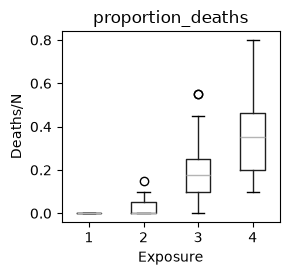

In [14]:
# Examine proportion of deaths by Exposure
df['proportion_deaths'] = df['Deaths'] / df['N']

fig, ax = plt.subplots(figsize=(3, 3))
df.boxplot(column='proportion_deaths', by='Exposure', ax=ax)
plt.suptitle('') 
plt.grid(False)
plt.ylabel('Deaths/N')

plt.tight_layout() 
# fig_path = os.path.join(fig_save_dir, 'snails.pdf')
# plt.savefig(fig_path, bbox_inches='tight')  

In [15]:
# Change baseline of Exposure
df['Exposure'] = pd.Categorical(df['Exposure'], categories=[2, 1, 3, 4], ordered=True)

fm = glm('Deaths + fail ~ Exposure', df, family=Binomial()).fit() 
print(fm.summary2(), '\n')
print(drop1_glm(fm))

                   Results: Generalized linear model
Model:                 GLM                   Method:            IRLS    
Model Family:          Binomial              AIC:               349.2384
Link Function:         Logit                 BIC:               359.4958
Dependent Variable:    ['Deaths', 'fail']    Log-Likelihood:    -170.62 
Date:                  2026-09-29 14:43      LL-Null:           -349.29 
No. Observations:      96                    Deviance:          182.38  
Df Model:              3                     Pearson chi2:      177.    
Df Residuals:          92                    Scale:             1.0000  
------------------------------------------------------------------------
               Coef.    Std.Err.     z     P>|z|     [0.025     0.975]  
------------------------------------------------------------------------
Intercept      -3.5051     0.2712 -12.9223 0.0000     -4.0368    -2.9735
Exposure[T.1] -23.0609 16254.7623  -0.0014 0.9989 -31881.8096 31835.687

In [16]:
# Read Morph dataset
df = pd.read_csv('dataset/case2102.txt', sep=' ')
print(df.head(), '\n')

# convert Morph to categorical variable 
df['Morph'] = pd.Categorical(df['Morph'])
print(df['Morph'].cat.categories)
print(df.info(), '\n')

# Create a variable to represent failures
df['fail'] = df['Placed'] - df['Removed']

# Fit GLM 
fm = glm('Removed + fail ~ Morph * Distance', df, family=Binomial()).fit() 
print(fm.summary2())

   Morph  Distance  Placed  Removed
1  light       0.0      56       17
2   dark       0.0      56       14
3  light       7.2      80       28
4   dark       7.2      80       20
5  light      24.1      52       18 

Index(['dark', 'light'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 1 to 14
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Morph     14 non-null     category
 1   Distance  14 non-null     float64 
 2   Placed    14 non-null     int64   
 3   Removed   14 non-null     int64   
dtypes: category(1), float64(1), int64(2)
memory usage: 498.0 bytes
None 

                   Results: Generalized linear model
Model:                  GLM                   Method:           IRLS   
Model Family:           Binomial              AIC:              83.9044
Link Function:          Logit                 BIC:              86.4606
Dependent Variable:     ['Removed', 'fail']   Log-Likelihood:   -37.9

In [17]:
# Estimate dispersion parameter 
print(fm.deviance, fm.df_resid)
disp = fm.deviance / fm.df_resid
print(disp)

# Adjust CI using quasi-likelihood
beta = np.array(fm.params)
SE_adj = np.sqrt(disp) * np.array(fm.bse)
CI_adj = np.column_stack((beta - norm.ppf(0.975) * SE_adj, beta + norm.ppf(0.975) * SE_adj))
print(CI_adj)
pvalue_adj = 2 * norm.sf(np.abs(beta/SE_adj))
print(pvalue_adj)


13.229902458901847 10
1.3229902458901848
[[-1.57514089 -0.68283221]
 [-0.20754621  1.03006048]
 [ 0.00577555  0.03122897]
 [-0.04601676 -0.00956133]]
[7.06173684e-07 1.92713603e-01 4.37988161e-03 2.80753304e-03]
